Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 3.90MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 37.7kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:05<00:00, 324kB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 1.12MB/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Epoch [1/10], Total Loss: 11255731.7598, BCE Loss: 10922342.2607, KL Loss: 333389.4920
Epoch [2/10], Total Loss: 10101828.8740, BCE Loss: 9785901.5371, KL Loss: 315927.3320
Epoch [3/10], Total Loss: 9838836.8506, BCE Loss: 9514289.3447, KL Loss: 324547.5482
Epoch [4/10], Total Loss: 9686193.1895, BCE Loss: 9357302.3545, KL Loss: 328890.8389
Epoch [5/10], Total Loss: 9584597.6182, BCE Loss: 9252952.3906, KL Loss: 331645.2103
Epoch [6/10], Total Loss: 9510428.6836, BCE Loss: 9174663.9316, KL Loss: 335764.7362
Epoch [7/10], Total Loss: 9444978.4375, BCE Loss: 9107302.5977, KL Loss: 337675.8311
Epoch [8/10], Total Loss: 9391061.9463, BCE Loss: 9051853.9785, KL Loss: 339207.9311
Epoch [9/10], Total Loss: 9347306.3594, BCE Loss: 9006115.6445, KL Loss: 341190.7229
Epoch [10/10], Total Loss: 9311374.6758, BCE Loss: 8967228.2051, KL Loss: 344146.4828


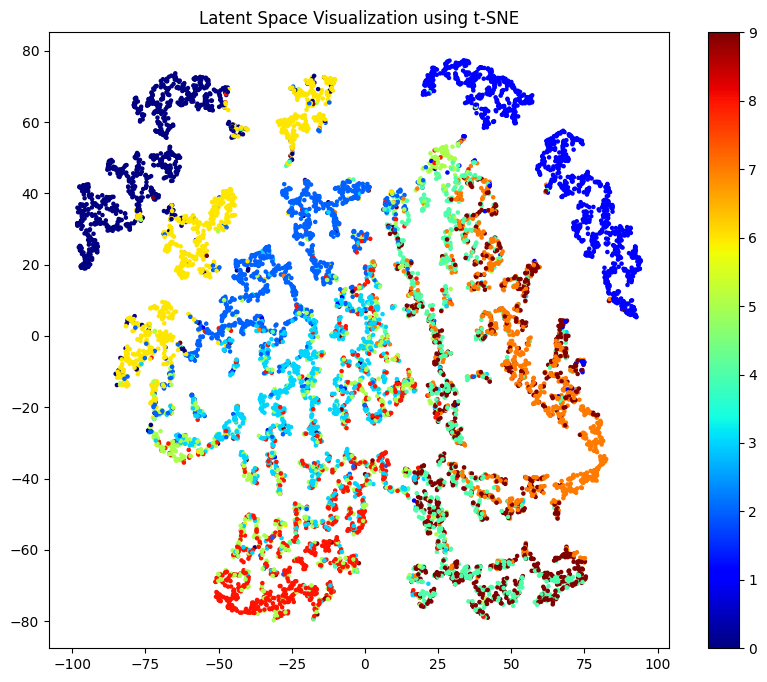

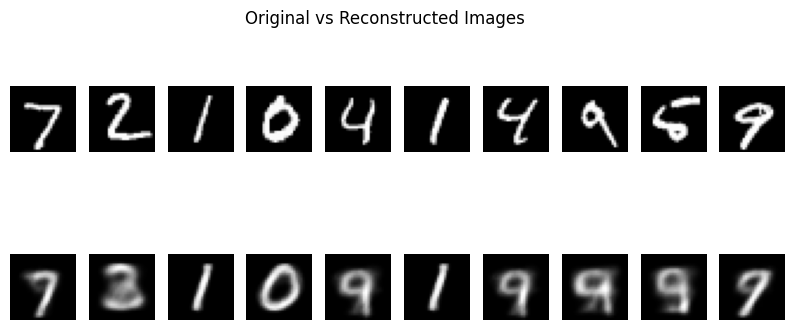

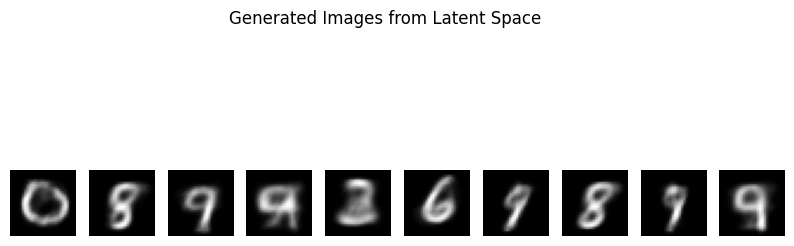

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Load and normalize the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the VAE components
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=2):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=512, output_dim=784):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        z = torch.relu(self.fc1(z))
        reconstruction = torch.sigmoid(self.fc_out(z))
        return reconstruction

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(z)
        return reconstruction, mu, logvar

# Loss function
def vae_loss(reconstruction, x, mu, logvar):
    # Binary Cross-Entropy Loss for reconstruction
    bce_loss = nn.functional.binary_cross_entropy(reconstruction, x, reduction='sum')
    # KL Divergence Loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce_loss + kl_loss, bce_loss, kl_loss

# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Training loop
num_epochs = 10
vae.train()

for epoch in range(num_epochs):
    total_loss = 0
    total_bce_loss = 0
    total_kl_loss = 0

    for batch in train_loader:
        x, _ = batch
        x = x.view(-1, 784).to(device)  # Flatten images

        # Forward pass
        reconstruction, mu, logvar = vae(x)

        # Compute loss
        loss, bce_loss, kl_loss = vae_loss(reconstruction, x, mu, logvar)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce_loss += bce_loss.item()
        total_kl_loss += kl_loss.item()

    print(f"Epoch [{epoch + 1}/{num_epochs}], Total Loss: {total_loss:.4f}, BCE Loss: {total_bce_loss:.4f}, KL Loss: {total_kl_loss:.4f}")

# Visualization: Latent Space
vae.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        x = x.view(-1, 784).to(device)
        mu, _ = vae.encoder(x)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(y.numpy())

latent_vectors = np.concatenate(latent_vectors)
labels = np.concatenate(labels)

# Use t-SNE to visualize latent space
tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='jet', s=5)
plt.colorbar()
plt.title("Latent Space Visualization using t-SNE")
plt.show()

# Reconstruction Visualization
examples = iter(test_loader)
example_data, _ = next(examples)
example_data = example_data.view(-1, 784).to(device)
with torch.no_grad():
    reconstructions, _, _ = vae(example_data)

plt.figure(figsize=(10, 4))
for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(example_data[i].cpu().numpy().reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructions[i].cpu().numpy().reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images")
plt.show()

# Generate new images by sampling random points in the latent space
samples = torch.randn(10, 2).to(device)
with torch.no_grad():
    generated_images = vae.decoder(samples)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].cpu().numpy().reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Images from Latent Space")
plt.show()
